# Week 1 — Analyzing and Cleaning Metadata



In [ ]:
import pandas as pd
import numpy as np


In [ ]:
data = pd.read_csv('/content/train-metadata.csv')

/tmp/ipykernel_5451/1247730119.py:1: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/train-metadata.csv')


In [ ]:
data.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [ ]:
#  (rows , col)
data.shape

(401059, 55)

In [ ]:
#  missing values
data.isnull().sum()

,0
isic_id,0
target,0
patient_id,0
age_approx,2798
sex,11517
anatom_site_general,5756
clin_size_long_diam_mm,0
image_type,0
tbp_tile_type,0
tbp_lv_A,0


In [ ]:
data['target'].value_counts()

,count
target,
0,400666
1,393


In [ ]:
data.describe()

,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.000000,398261.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,63.000000,4.010590e+05
mean,0.000980,58.012986,3.930827,19.974007,14.919247,28.281706,26.913015,34.786341,30.921279,54.653689,...,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.670952,9.716220e+01
std,0.031288,13.596165,1.743068,3.999489,3.529384,5.278676,4.482994,5.708469,4.829345,5.520849,...,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.792798,8.995782e+00
min,0.000000,5.000000,1.000000,-2.487115,-9.080269,-0.730989,9.237066,3.054228,11.846520,-1.574164,...,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.200000,1.261082e-16
25%,0.000000,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,...,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.300000,9.966882e+01
50%,0.000000,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,...,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.400000,9.999459e+01
75%,0.000000,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,...,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.600000,9.999996e+01
max,1.000000,85.000000,28.400000,48.189610,37.021680,54.306900,48.372700,58.765170,54.305290,105.875784,...,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,5.000000,1.000000e+02


In [ ]:
print(data['clin_size_long_diam_mm'].describe())


count    401059.000000
mean          3.930827
std           1.743068
min           1.000000
25%           2.840000
50%           3.370000
75%           4.380000
max          28.400000
Name: clin_size_long_diam_mm, dtype: float64


In [ ]:
print((data['clin_size_long_diam_mm'] > 20).sum())

79


In [ ]:
print(data['sex'].mode()[0])
print(data['sex'].value_counts())

male
sex
male      265546
female    123996
Name: count, dtype: int64


In [ ]:
print(data['anatom_site_general'].value_counts())

anatom_site_general
posterior torso    121902
lower extremity    103028
anterior torso      87770
upper extremity     70557
head/neck           12046
Name: count, dtype: int64


Cell — Age vs Target:


In [ ]:
data.groupby('target')['age_approx'].mean()

,age_approx
target,
0,58.009694
1,61.371795


Cell — Body Site vs Cancer Rate

In [ ]:
site_stats = data.groupby('anatom_site_general')['target'].agg(['sum', 'count'])
site_stats['cancer_rate'] = site_stats['sum'] / site_stats['count'] * 100
print(site_stats.sort_values('cancer_rate', ascending=False))

                     sum   count  cancer_rate
anatom_site_general                          
head/neck             78   12046     0.647518
anterior torso        82   87770     0.093426
posterior torso      103  121902     0.084494
upper extremity       57   70557     0.080786
lower extremity       73  103028     0.070855


Cell — Sex vs Cancer Rate:

In [ ]:
sex_stats = data.groupby('sex')['target'].agg(['sum', 'count'])
sex_stats['cancer_rate'] = sex_stats['sum'] / sex_stats['count'] * 100
print(sex_stats)

        sum   count  cancer_rate
sex                             
female  109  123996     0.087906
male    274  265546     0.103184


Cell — Age Distribution by Target:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

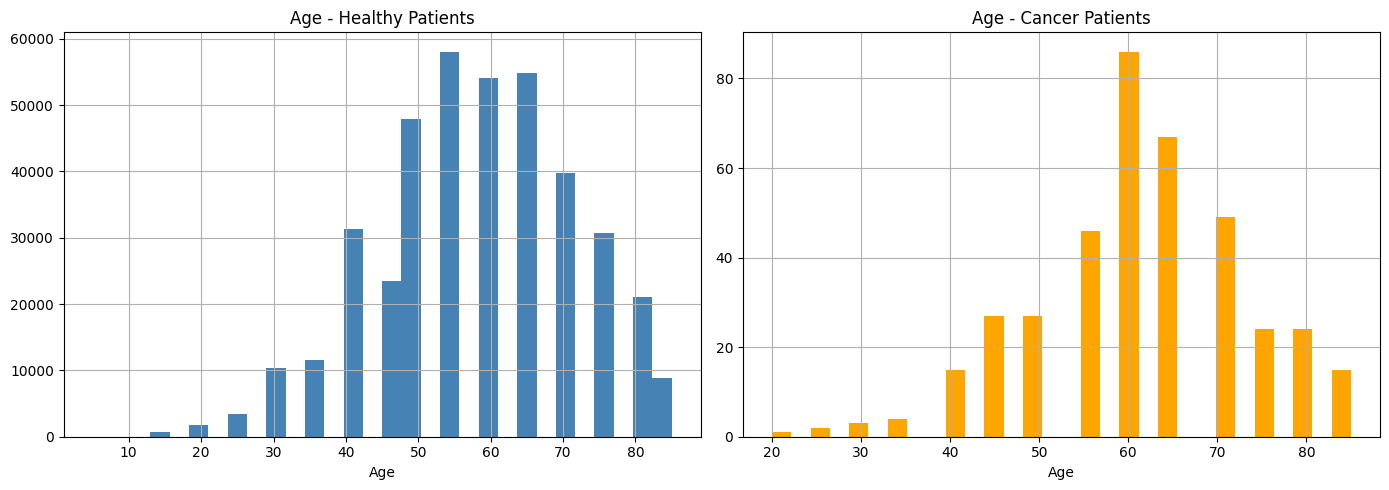

In [ ]:

# plt.figure(figsize=(10, 5))
# sns.histplot(data=data, x='age_approx', hue='target', bins=30,stat='density')
# plt.title('Age Distribution by Target')
# plt.xlabel('Age')
# plt.ylabel('Count')
# plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data[data['target']==0]['age_approx'].hist(
    bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Age - Healthy Patients')
axes[0].set_xlabel('Age')

data[data['target']==1]['age_approx'].hist(
    bins=30, ax=axes[1], color='orange')
axes[1].set_title('Age - Cancer Patients')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

Cell — Cancer Rate by Body Site

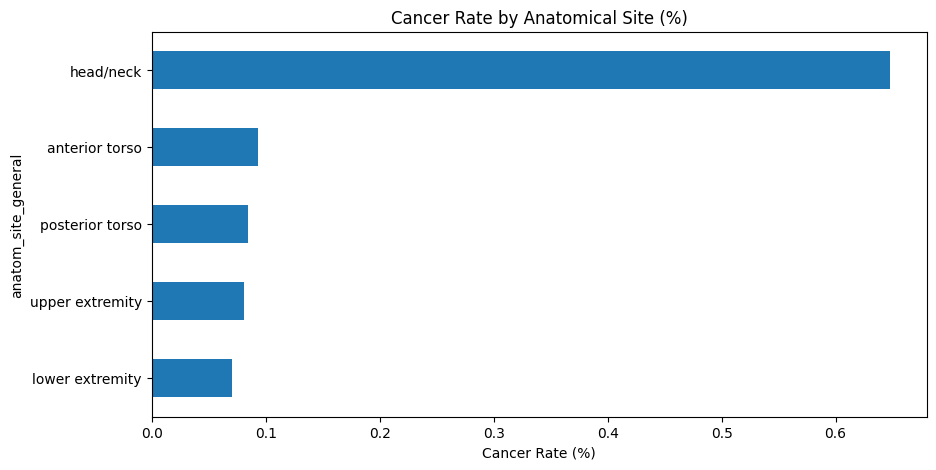

In [ ]:
plt.figure(figsize=(10, 5))
site_stats['cancer_rate'].sort_values().plot(kind='barh')
plt.title('Cancer Rate by Anatomical Site (%)')
plt.xlabel('Cancer Rate (%)')
plt.show()

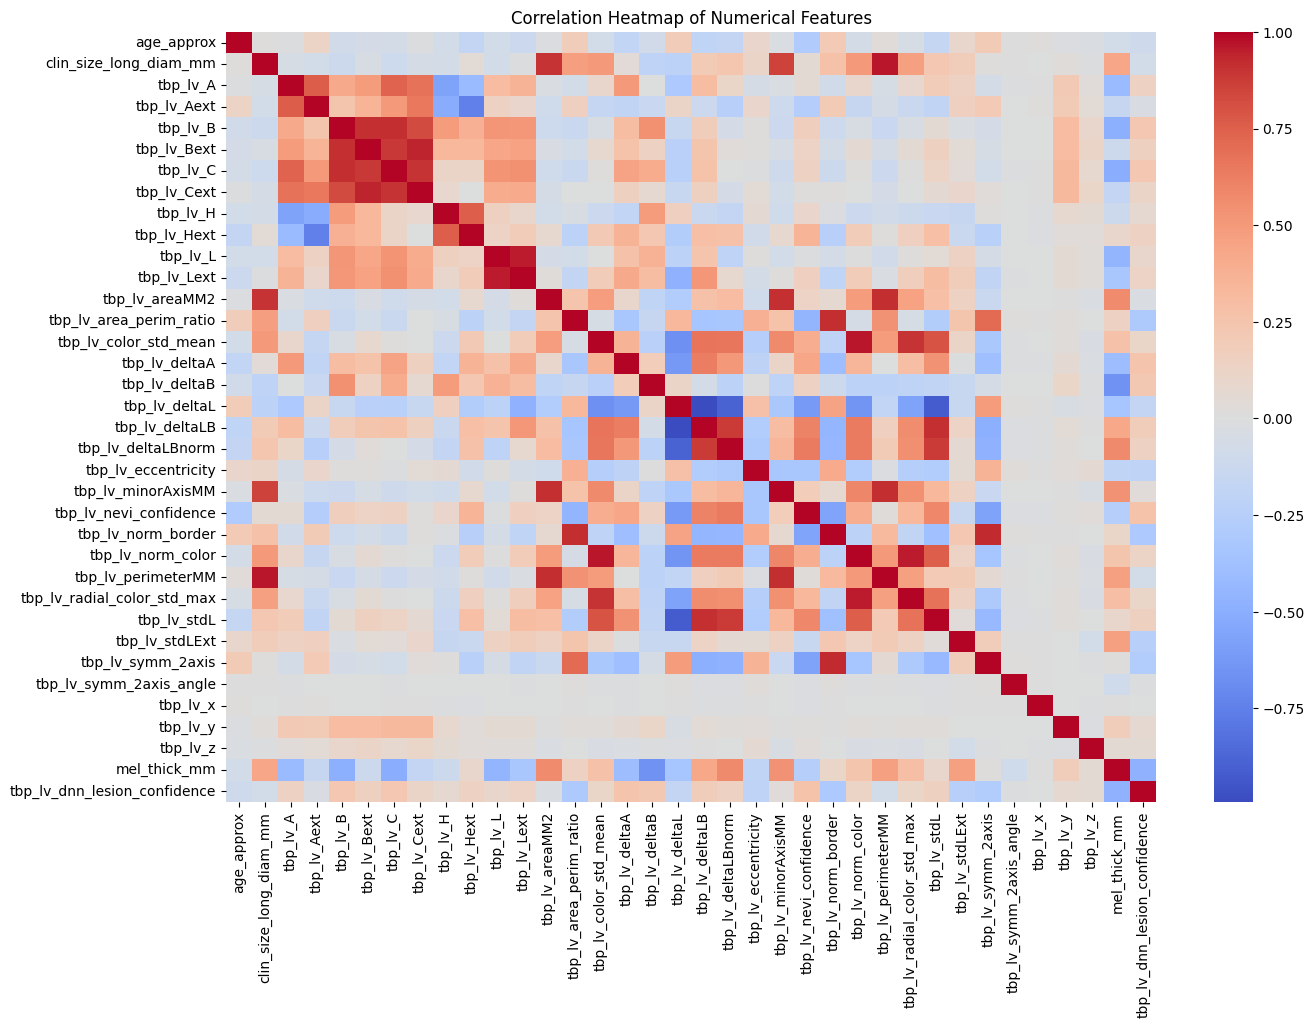

In [ ]:
plt.figure(figsize=(15,10))

numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()

numerical_cols = [col for col in numerical_cols if col != 'target']

sns.heatmap(data[numerical_cols].corr(), cmap='coolwarm',center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Key EDA Findings

1. Extreme class imbalance: 1 cancer per 1,019 healthy cases
2. Age is a strong predictor — cancer peaks at age 60-70
3. Head/neck has 6x higher cancer rate than lower extremity
4. Many tbp_lv_ features are highly correlated pairs
5. Several columns must be dropped due to leakage/redundancy
6. Standard accuracy metric is invalid — will use PR-AUC